# Markov Chain Comparison
In this file, we use data of trajectories of choanoflagelates confined in a 2D plan before and after addition of different substances:
- **RS39604** is a synthetic agonist that activates our ion channel.
- **15M9E** is a natural product purified from bacteria that also activates the channel.
- **Algoriphagus** machipongonensis is the bacterium from which 15M9E was purified, and a natural prey source for this choanoflagellate species.

The notebook is organized as follow:
1. Import and convert the data.
2. Make the embedding.
3. Clusterize all the data togethers and Make the Markov chains
4. Compare the Markov Chains.


# Import the xml files and convert xml into dataframes

In [1]:
import sys
sys.path.append('../../src')
from xml_df_parser import trackmate_xml_to_df
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
folder = "../../data/Algoriphagus/"
xml_files = ["Expt1_251217_Pre", "Expt1_251217_Post"]
ext = ".xml"
dfs = list()
for file in xml_files:
    dfs.append(trackmate_xml_to_df(folder+file+ext))


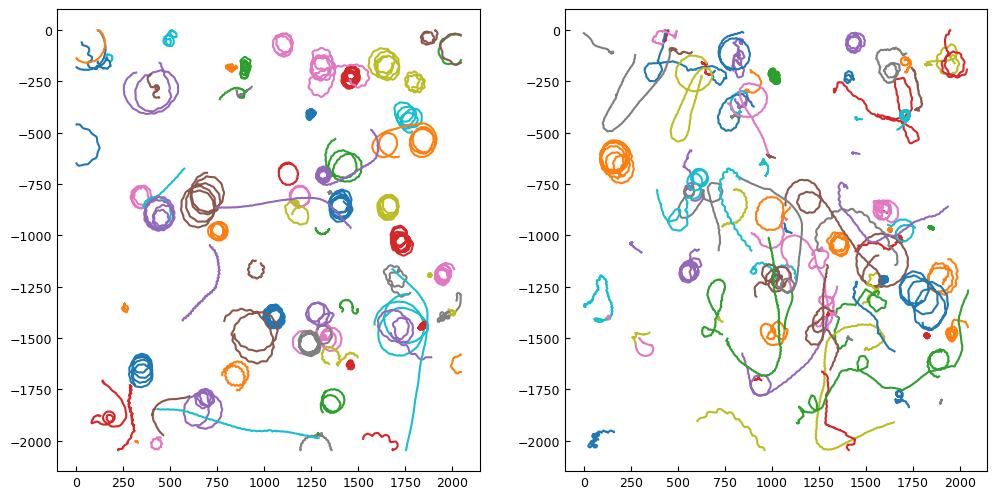

In [3]:
fig,ax = plt.subplots(ncols=len(dfs),figsize=(6*len(dfs),6))
for i in range(len(dfs)):
    for id,track in dfs[i].groupby('Track_ID'):
        ax[i].plot(track['X'],-track['Y'])



In [4]:
print(dfs[0].head())

     Spot_ID  Track_ID  Frame           X            Y    Z
0       2178         0      0  400.400844  1634.425105  0.0
69      2483         0      1  399.938974  1629.545128  0.0
124     2627         0      2  399.417460  1626.611111  0.0
157     2696         0      3  399.428875  1624.386412  0.0
213     2582         0      4  399.416402  1622.438624  0.0


## Currate and make embedding

In [5]:
sys.path.append('../..')
from src.embedding_trans import EmbeddingTrans
columns_abs = []
columns_translated = ['X','Y']
id = 'Track_ID'
time = 'Frame'
cols = ['X','Y']


In [6]:
emb = EmbeddingTrans(dfs[0], columns=columns_abs,columns_translated = columns_translated,ID_NAME=id)

In [7]:
K = 10
emb.make_embedding(K)

In [8]:
n_clusters = 10
emb.make_cluster(n_clusters=n_clusters)

(array([3, 3, 3, ..., 4, 4, 4], shape=(33498,)),
 array([[ 3.04654644e+00, -2.81500853e-01,  2.39997260e+00,
         -1.14301596e-01,  1.73013524e+00,  3.74762707e-02,
          1.05068428e+00,  1.52491913e-01,  3.49043841e-01,
          2.21658715e-01, -3.38752907e-01,  2.35720299e-01,
         -1.03605200e+00,  1.82811503e-01, -1.73165670e+00,
          7.03456474e-02, -2.40394785e+00, -1.10666707e-01,
         -3.06597294e+00, -3.94035191e-01],
        [ 1.70263646e+01, -3.18837487e+00,  1.38031502e+01,
         -1.41147628e+00,  1.03438697e+01,  3.35757018e-01,
          6.46062451e+00,  1.79823316e+00,  2.16918206e+00,
          2.57413746e+00, -2.28069034e+00,  2.43967773e+00,
         -6.51374096e+00,  1.52342616e+00, -1.03274984e+01,
          1.55428358e-01, -1.37462555e+01, -1.36427878e+00,
         -1.69350058e+01, -2.86252996e+00],
        [ 5.76177929e+00, -6.10972978e-01,  4.55594542e+00,
         -2.50038180e-01,  3.28861843e+00,  7.33213042e-02,
          1.98875090e+0

In [9]:
from src.markov_analysis import Markov
mkv = Markov(emb,tau=1)